In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load data
df = pd.read_csv("D:/SALEM/Machine Learning Models/1-Citizen Trust Score Model/Dataset/citizen_trust_dataset.csv")

features = [
    "valid_ratio",
    "duplicate_rate",
    "fake_image_ratio",
    "reports_last_30_days",
    "avg_severity_reported"
]

X = df[features]
y = df["trust_label"]

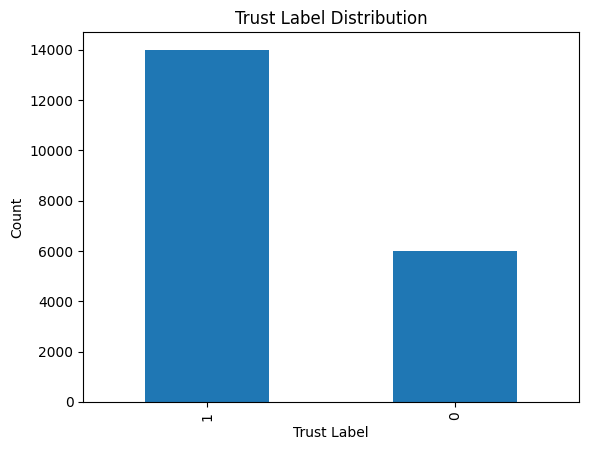

In [14]:
df["trust_label"].value_counts().plot(
    kind="bar",
    title="Trust Label Distribution"
)
plt.xlabel("Trust Label")
plt.ylabel("Count")
plt.show()

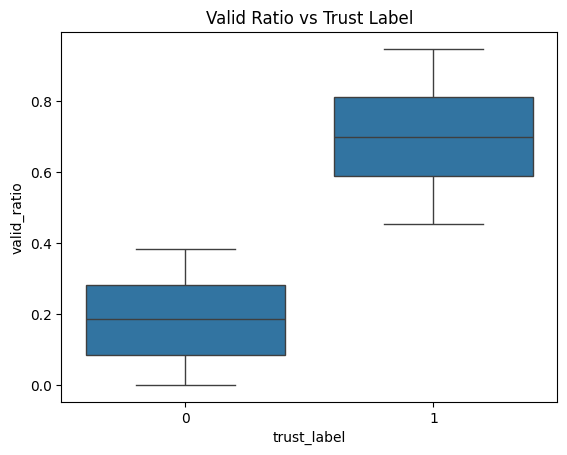

In [16]:
sns.boxplot(
    x="trust_label",
    y="valid_ratio",
    data=df
)
plt.title("Valid Ratio vs Trust Label")
plt.show()

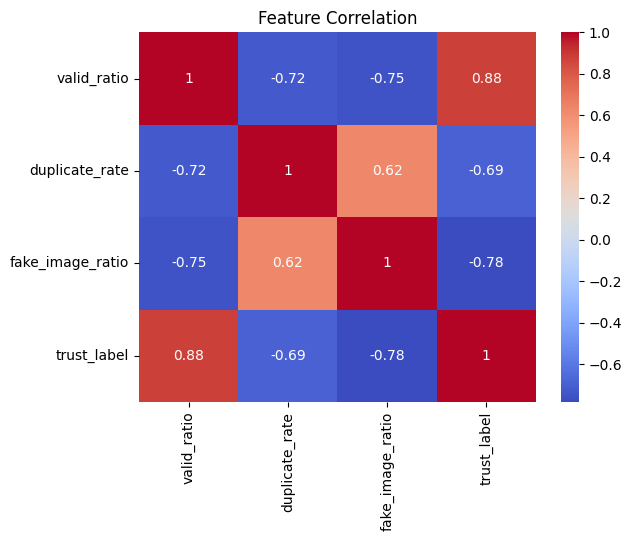

In [17]:
corr = df[
    ["valid_ratio", "duplicate_rate", "fake_image_ratio", "trust_label"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [6]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [8]:
# Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1171
           1       1.00      1.00      1.00      2829

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [10]:
# Trust Score
df["trust_score"] = model.predict_proba(X)[:, 1]
df.to_csv("D:/SALEM/Machine Learning Models/1-Citizen Trust Score Model/Dataset/citizen_trust_with_score.csv", index=False)

In [18]:
import joblib

joblib.dump(model, "D:/SALEM/Machine Learning Models/1-Citizen Trust Score Model/modelpk/trust_model.pkl")
print("✅ Trust model saved")

✅ Trust model saved
